In [1]:
import pandas as pd
import glob

meta_files = glob.glob("/kaggle/input/**/uncertainty_*_meta.csv", recursive=True)
all_meta = pd.concat([pd.read_csv(f) for f in meta_files], ignore_index=True)

summary = all_meta.groupby(["finding"]).agg(
    n_images=("image_id", "nunique"),
    mean_variance=("variance_mean", "mean"),
    max_variance=("variance_max", "max"),
    std_variance=("variance_mean", "std"),
).round(4)
print(summary)

               n_images  mean_variance  max_variance  std_variance
finding                                                           
Atelectasis         138         0.0105        0.2132        0.0021
Cardiomegaly        541         0.0091        0.1969        0.0018
Consolidation       254         0.0103        0.2260        0.0018
Nodule/Mass         578         0.0102        0.2282        0.0019
Pneumothorax         96         0.0102        0.1991        0.0019


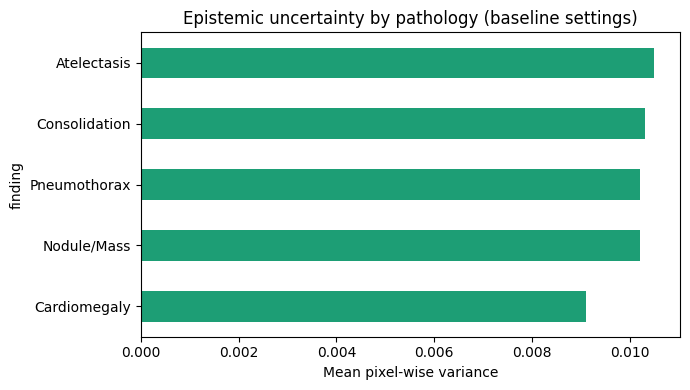

In [2]:
import matplotlib.pyplot as plt

class_stats = summary["mean_variance"]  # from the groupby table above
fig, ax = plt.subplots(figsize=(7, 4))
class_stats.sort_values().plot.barh(ax=ax, color="#1D9E75")
ax.set_xlabel("Mean pixel-wise variance")
ax.set_title("Epistemic uncertainty by pathology (baseline settings)")
plt.tight_layout()
plt.savefig("/kaggle/working/variance_by_class.png", dpi=150)
plt.show()